In [1]:
import os
import sys
mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [2]:
%pwd
%load_ext autoreload
%autoreload 2

In [3]:
import torch
from torch.distributions import constraints
import lib.distributions as distr
import matplotlib.pyplot as plt
from lib.distributions.utils.visualization import plot_mgvm_distr_1d, plot_mgvm_distr_2d
from sklearn.datasets import make_spd_matrix
from lib.distributions import VonMisesFisher

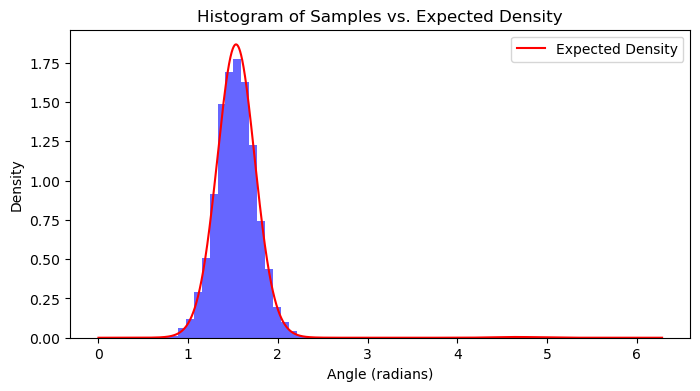

Sample Mean: 1.5400, Expected Mean: 1.5708
Sample Variance: 0.0744


In [4]:
loc = torch.tensor([torch.pi/2])
scale = torch.tensor([3.0])
precision = 10 * torch.tensor(make_spd_matrix(n_dim=2)).type(torch.float32)
#precision = torch.eye(2)

plot_mgvm_distr_1d(loc, scale, precision, num_samples=10000)


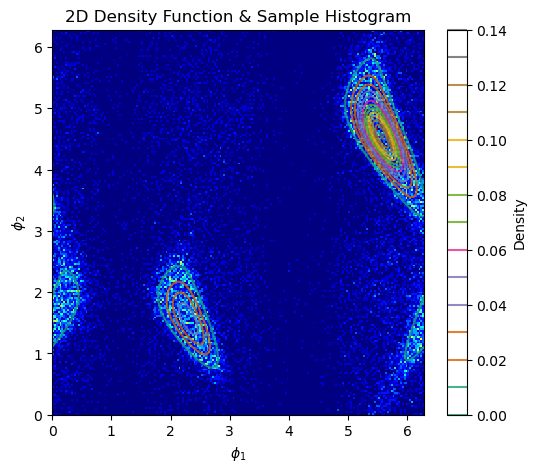

In [8]:
# Define test parameters
loc = torch.tensor([0.19, 2.34])
scale = torch.tensor([1.0,0.1])
precision = 10 * torch.tensor(make_spd_matrix(n_dim=4,random_state=12)).type(torch.float32)
#precision = 4*torch.eye(4) + 3*torch.tensor([[0.0,0.5,1.0,0.5],[0.5,0.0,0.0,0.0],[1.0,0.0,0.0,0.0],[.5,0.0,0.0,0.0]])

plot_mgvm_distr_2d(loc=loc, scale=scale, precision=precision, num_samples=20000)



In [11]:
loc = torch.tensor([torch.pi, torch.pi/2])
loc_batch= loc.repeat(3,1)
scale = torch.tensor([[300.0],[1000.0]])
scale_batch= scale.repeat(3,1,1)

x = torch.cos(loc_batch)  # Shape: [batch_size, num_angles]
y = torch.sin(loc_batch)  # Shape: [batch_size, num_angles]
loc_cartesian = torch.stack((x, y), dim=-1)  # Shape: [batch_size, num_angles, 2]
proposal_distr = VonMisesFisher(loc_cartesian, scale_batch)
sample = proposal_distr.rsample()
angles = torch.atan2(sample[:, :, 1], sample[:, :, 0])


In [51]:
num_samples = 3
loc = torch.tensor([0.19, 2.], requires_grad=True)
scale = torch.tensor([5.0], requires_grad=True)
precision = torch.eye(4, requires_grad=True)

loc_batch = loc.repeat(num_samples, 1)
scale_batch = scale.repeat(num_samples, 1)
precision_batch = precision.repeat(num_samples, 1, 1)

# Instantiate the distribution
mg_vm = distr.MGVonMises(loc_batch, scale_batch, precision_batch)
vm = distr.VonMisesFisher(loc_batch, scale_batch)

std = torch.exp(0.5 * scale_batch)
eps = torch.randn_like(std)
sample3 = loc_batch + eps * std
print(sample3)

# Sample with gradients
sample = mg_vm.rsample(loc_batch.shape)
sample2 = vm.rsample()
print("sample",sample)

#grad = torch.autograd.grad(sample2, loc)  # Compute dy/dx
#print(grad)  # Output: (tensor(12.),)

# Dummy loss to backpropagate
loss = (sample.sum())
loss.backward()

# Check gradients
print("loc grad:", loc.grad)
print("scale grad:", scale.grad)
print("precision grad:", precision.grad)

tensor([[ -8.4918,  -6.6818],
        [ 22.0465,  23.8565],
        [-14.1837, -12.3737]], grad_fn=<AddBackward0>)
sample tensor([[ 0.9218, -2.8790],
        [-4.9538, -3.4574],
        [ 0.5547, -3.8193]], grad_fn=<SubBackward0>)
loc grad: None
scale grad: tensor([-6.])
precision grad: None


In [33]:
# Define mean (mu) and log-variance (log_var)
mu = torch.tensor([0.5], requires_grad=True)
log_var = torch.tensor([-0.5], requires_grad=True)

# Compute standard deviation (sigma)
sigma = torch.exp(0.5 * log_var)  # Ensures positivity

# Sample epsilon ~ N(0, 1)
epsilon = torch.randn_like(mu)

# Reparameterization trick
z = mu + sigma * epsilon  # This allows gradients to flow

# Define a simple loss (e.g., sum of z) to check gradients
loss = z.sum()

# Perform backpropagation
loss.backward()

# Print gradients
print("Gradient of mu:", mu.grad)
print("Gradient of log_var:", log_var.grad)  # Should be nonzero


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [52]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Set seed
torch.manual_seed(1)

def unwrap(theta):
    alpha = torch.exp(theta[0]) + 1
    beta = torch.exp(theta[1])
    return alpha, beta

def wrap(alpha, beta):
    return torch.tensor([torch.log(alpha - 1), torch.log(beta)], requires_grad=True)

def log_q(z, theta):
    alpha, beta = unwrap(theta)
    return torch.lgamma(alpha) + alpha * torch.log(beta) + (alpha - 1) * torch.log(z) - beta * z

def log_s(epsilon):
    return -0.5 * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * epsilon ** 2

def h(epsilon, theta):
    alpha, beta = unwrap(theta)
    return (alpha - 1. / 3.) * (1 + epsilon / torch.sqrt(9 * alpha - 3)) ** 3 / beta

def dh(epsilon, theta):
    alpha, beta = unwrap(theta)
    return (alpha - 1. / 3) * 3. / torch.sqrt(9 * alpha - 3.) * (1 + epsilon / torch.sqrt(9 * alpha - 3)) ** 2 / beta

def log_r(epsilon, theta):
    return -torch.log(dh(epsilon, theta)) + log_s(epsilon)

def log_pi(epsilon, theta):
    return log_s(epsilon) + log_q(h(epsilon, theta), theta) - log_r(epsilon, theta)

def h_inverse(z, theta):
    alpha, beta = unwrap(theta)
    return torch.sqrt(9.0 * alpha - 3) * ((beta * z / (alpha - 1. / 3)) ** (1. / 3) - 1)

def sample_pi(theta, size=1):
    alpha, beta = unwrap(theta)
    gamma_samples = torch.distributions.Gamma(alpha, 1. / beta).sample((size,))
    return h_inverse(gamma_samples, theta)

def log_p(x, z):
    lp = -torch.lgamma(a0) + a0 * torch.log(b0) + (a0 - 1) * torch.log(z) - b0 * z
    ll = torch.sum(-torch.lgamma(x[:, None] + 1) - z[None, :] + x[:, None] * torch.log(z[None, :]), dim=0)
    return lp + ll

def gamma_entropy(theta):
    alpha, beta = unwrap(theta)
    return alpha - torch.log(beta) + torch.lgamma(alpha) + (1 - alpha) * torch.digamma(alpha)

def reparam_objective(theta):
    epsilon = sample_pi(theta, size=10)
    return torch.mean(log_p(x, h(epsilon, theta)))

def elbo(theta):
    return reparam_objective(theta) + gamma_entropy(theta)

a0, b0 = 1.0, 1.0
z_true = 3.0
N = 10
x = torch.poisson(torch.tensor([z_true] * N))

alpha_true = a0 + x.sum()
beta_true = b0 + N

theta = wrap(torch.tensor(2.0), torch.tensor(2.0))
optimizer = optim.SGD([theta], lr=0.05)
elbo_values = []

for _ in range(300):
    optimizer.zero_grad()
    loss = -elbo(theta)
    loss.backward()
    optimizer.step()
    elbo_values.append(elbo(theta).item())

alpha_star, beta_star = unwrap(theta)
print("true a =", alpha_true.item())
print("infd a =", alpha_star.item())
print("true b =", beta_true.item())
print("infd b =", beta_star.item())
print("E_q(z; theta)[z] =", (alpha_star / beta_star).item())

plt.plot(elbo_values)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.show()


TypeError: lgamma(): argument 'input' (position 1) must be Tensor, not float